## AGE AT DIAGNOSIS STUDY

### Model 1: Feature Selection with Recursive Feature Elimination with Cross-Validation (RFE-CV)

In [6]:
# ----------------------------------------------------------------------------------------------------------------------------
# IMPORT LIBRARIES
# ----------------------------------------------------------------------------------------------------------------------------
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, recall_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from imblearn.pipeline import Pipeline
import shap

# ----------------------------------------------------------------------------------------------------------------------------
# PATH
# ----------------------------------------------------------------------------------------------------------------------------
# Main directory where all analysis results will be stored
path = "../results/AgeAtDiagnosis_Model1"
input_file = "../data/Base mama FIS 2012-2014 TOR TGN Para IA.csv"

# Create the output directory
os.makedirs(path, exist_ok=True)

# Feature selection method used in this analysis
feature_selection_method = 'RECURSIVE'

# ----------------------------------------------------------------------------------------------------------------------------
# LOAD AND CLEAN DATA
# ----------------------------------------------------------------------------------------------------------------------------
db = pd.read_csv(input_file,
    sep=";",
)

# Replace commas with dots 
db = db.replace(',', '.', regex=True)

# Replace empty strings with NaN
db = db.replace(r'^\s*$', np.nan, regex=True)

# Ensure DFS120 is stored as a numerical variable
db['DFS120'] = pd.to_numeric(db['DFS120'], errors='coerce')

# Remove variables that are not required for this analysis
db = db.drop(columns=['Cas', 'Stamenopa', 'OS120', 'DFS120', 'Tracneoad',
                      'Statuspesur', 'StatusOS120', 'Nºganglis', 'Invavasc',
                      'Luminal', 'Invaperin'], errors='ignore')

# Convert numerical variables to float
columns_float = ['Edat', 'GangMeta', 'CD4Intra_M', 'CD4GN_M', 'CD8Intra_M', 'CD8GN_M',
                 'CD57Intra_M', 'CD57GN_M', 'FOXP3Intra_M_bis', 'FOXP3GN_M_bis',
                 'CD21Intra_M', 'CD21GN_M', 'CD68Intra_M', 'CD68GN_M', 'CD1AIntra_M',
                 'CD1AGN_M', 'CD123Intra_M', 'CD123GN_M', 'S100Intra_M', 'S100GN_M',
                 'LAMP3Intra_M', 'LAMP3GN_M', 'CD83Intra_M', 'CD83GN_M']

for col in columns_float:
    if col in db.columns:
        db[col] = db[col].astype(float)

# Remove S100Intra_M from the analysis (extensive missing data) 
db = db.drop(columns=['S100Intra_M'], errors='ignore')

# Remove missing values and reset index
db = db.dropna().reset_index(drop=True)

print(f"Dataset shape after cleaning: {db.shape}")

# ----------------------------------------------------------------------------------------------------------------------------
# ENCODE CATEGORICAL VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
db = pd.get_dummies(db, columns=['Grau', 'RE', 'RP', 'HER2', 'KI67', 'NodalStatus'], drop_first=True)
db = pd.get_dummies(db, columns=['StatusDFS120'])
db = db.drop(columns=['StatusDFS120_No'], errors='ignore')

# ----------------------------------------------------------------------------------------------------------------------------
# RENAME VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
variable_names = ['Age', 'Tumor Diameter', 'GangMeta', 'CD4 Intra', 'CD4 ALN-', 'CD8 Intra', 'CD8 ALN-',
                  'CD57 Intra', 'CD57 ALN-', 'FOXP3 Intra', 'FOXP3 ALN-', 'CD21 Intra', 'CD21 ALN-',
                  'CD68 Intra', 'CD68 ALN-', 'CD1A Intra', 'CD1A ALN-', 'CD123 Intra', 'CD123 ALN-',
                  'S100 ALN-', 'LAMP3 Intra', 'LAMP3 ALN-', 'CD83 Intra', 'CD83 ALN-',
                  'Histological Grade II', 'Histological Grade III',
                  'RE+', 'RP+', 'HER2-',
                  'KI67 low', 'KI67 medium',
                  'NodalStatus_no_metastasi', 'Recurrence']

db.columns = variable_names

# ----------------------------------------------------------------------------------------------------------------------------
# DEFINE THE BINARY TARGET VARIABLE
# ----------------------------------------------------------------------------------------------------------------------------
db['Age_binary'] = db['Age'].astype(float) > 60

# ----------------------------------------------------------------------------------------------------------------------------
# DEFINE FEATURE GROUPS
# ----------------------------------------------------------------------------------------------------------------------------
immune_features = ['CD4 Intra', 'CD4 ALN-', 'CD8 Intra', 'CD8 ALN-',
                  'CD57 Intra', 'CD57 ALN-', 'FOXP3 Intra', 'FOXP3 ALN-', 'CD21 Intra', 'CD21 ALN-',
                  'CD68 Intra', 'CD68 ALN-', 'CD1A Intra', 'CD1A ALN-', 'CD123 Intra', 'CD123 ALN-',
                  'S100 ALN-', 'LAMP3 Intra', 'LAMP3 ALN-', 'CD83 Intra', 'CD83 ALN-']

clinicopathological_features = [
    'Tumor Diameter',
    'GangMeta',
    'Histological Grade II',
    'Histological Grade III',
    'RE+',
    'RP+',
    'HER2-',
    'KI67 low',
    'KI67 medium',
    'NodalStatus_no_metastasi',
    'Recurrence'
]

# Combine all features
all_features = immune_features + clinicopathological_features

# Define numerical variables
variables_numericas = immune_features + ['Tumor Diameter', 'GangMeta']

# ----------------------------------------------------------------------------------------------------------------------------
# PREPARE FEATURES AND TARGET
# ----------------------------------------------------------------------------------------------------------------------------
# Predictor matrix
x = db[all_features]

# Binary target variable
y = db['Age_binary']

print("\nOriginal distribution:")
print(Counter(y))


# ----------------------------------------------------------------------------------------------------------------------------
# REPEATED TRAIN/TEST ANALYSIS
# ----------------------------------------------------------------------------------------------------------------------------
# The complete analysis is repeated for 100 random states.
# Each iteration uses:
#   - 80% of the data for training
#   - 20% of the data for testing
#   - stratification to preserve the target-class distribution

for i in range(0, 100):
    random_num = i
    # Create a separate directory for each random state
    os.makedirs(f'{path}/{feature_selection_method}_METHOD/{random_num}', exist_ok=True)

    new_file = open(f'{path}/{feature_selection_method}_METHOD/{random_num}/resultats_terminal.txt', 'w')
    new_file.write('Random State: ' + str(random_num) + '\n')
    
    #----------------------------------------------------------------------
    # TRAIN/TEST SPLIT
    #----------------------------------------------------------------------
    x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2,random_state=random_num,shuffle = True,stratify=y)
    
    #----------------------------------------------------------------------
    # CHECK CLASS DISTRIBUTION
    #----------------------------------------------------------------------
    counter = Counter(y)
    counter_test = Counter(y_test)
    new_file.write('\n' + 'y: '+ str(counter) + '\n')
    new_file.write('y test: ' + str(counter_test) + '\n')
    counter = Counter(y_train)
    new_file.write('y train: ' +str(counter) + '\n')
    
    #----------------------------------------------------------------------
    # STANDARDIZATION
    #----------------------------------------------------------------------
    scaler = StandardScaler()
    scaler_fit = scaler.fit(x_train[variables_numericas]) 
    
    x_train_scaled = x_train.copy()
    x_train_scaled[variables_numericas] = scaler_fit.transform(x_train[variables_numericas])
    x_test_scaled = x_test.copy()
    x_test_scaled[variables_numericas] = scaler_fit.transform(x_test[variables_numericas])

    # ------------------------------------------------------------
    # RANDOMIZED HYPERPARAMETER SEARCH
    # ------------------------------------------------------------
    # Three-fold stratified cross-validation is used for model selection
    cv = StratifiedKFold(3)  

    # Hyperparameter search space for logistic regression
    param_dist = {
        'classifier__C': np.logspace(-3, 3, 20),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear'],
        'classifier__max_iter': [500, 1000, 2000]
    }
    
    # ROC AUC is used as the optimization metric
    scoring = 'roc_auc'
    new_file.write('\n' + 'Scoring: ' + str(scoring) + '\n') 
    
    #----------------------------------------------------------------------
    # DEFINE LOGISTIC REGRESSION CLASSIFIER
    #----------------------------------------------------------------------
    lr_classifier = LogisticRegression(class_weight='balanced', random_state=random_num)

    #----------------------------------------------------------------------
    # FEATURE SELECTION + RANDOMIZED SEARCH
    #----------------------------------------------------------------------  
    if x_train_scaled.shape[1]==1:
        # Skip feature selection if only one feature
        pipeline = Pipeline([
            ('classifier', lr_classifier)
        ])
        random_search = RandomizedSearchCV(estimator = pipeline, scoring = scoring, param_distributions = param_dist, cv = cv, verbose=0, random_state=random_num, n_jobs = -1)
        random_search.fit(x_train_scaled,y_train)
        x_train_rfecv = x_train_scaled
        x_test_rfecv = x_test_scaled

    else:
        # Include Recursive Feature Elimination (RFECV) for feature selection
        pipeline = Pipeline([
            ('feature_selection', RFECV(estimator=lr_classifier, step=1, cv=cv, scoring=scoring)),
            ('classifier', lr_classifier)
        ])
        
        # Randomized hyperparameter search with 3-fold stratified cross-validation
        random_search = RandomizedSearchCV(estimator = pipeline, scoring = scoring, param_distributions = param_dist, cv = cv, verbose=0, random_state=random_num, n_jobs = -1)
        random_search.fit(x_train_scaled,y_train)

        # Get the selected features
        selected_features = x_train_scaled.columns[random_search.best_estimator_['feature_selection'].support_]
        
        # Transform the data to include only the selected features
        x_train_rfecv = random_search.best_estimator_['feature_selection'].transform(x_train_scaled)
        x_train_rfecv = pd.DataFrame(x_train_rfecv, columns=selected_features)
        x_test_rfecv = random_search.best_estimator_['feature_selection'].transform(x_test_scaled)
        x_test_rfecv = pd.DataFrame(x_test_rfecv, columns=selected_features)
         

    #----------------------------------------------------------------------
    # TRAIN FINAL LOGISTIC REGRESSION MODEL
    #----------------------------------------------------------------------
    # Retrieve the best hyperparameters identified by RandomizedSearchCV
    best_params = random_search.best_params_
    cleaned_best_params = {p.split('__')[1]: v for p, v in best_params.items()}

    # Create the final logistic regression model using the optimized hyperparameters
    best_lr = LogisticRegression(**cleaned_best_params, class_weight='balanced', random_state=random_num)

    # Fit the final model using the selected training features
    best_lr.fit(x_train_rfecv, y_train)

    # Generate predictions for the independent test set
    result_lr = best_lr.predict(x_test_rfecv)

    #----------------------------------------------------------------------
    # CROSS-VALIDATION PERFORMANCE
    #----------------------------------------------------------------------
    # Evaluate the final model using three-fold cross-validation on the training set
    scores = cross_val_score(best_lr, x_train_rfecv, y_train,cv=cv, scoring=scoring)
    new_file.write('\n' + 'Metricas cross_validation: ' + str(scores) )
    new_file.write('\n' + 'Media de cross_validation: ' + str(scores.mean()) +' ' + str(np.std(scores)) + '\n')

    #----------------------------------------------------------------------
    # TEST-SET PERFORMANCE
    #----------------------------------------------------------------------
    # Generate the classification report for the independent test set
    prec_rec = classification_report(y_test,result_lr)
    new_file.write('\n' + str(prec_rec) + '\n')

    # Calculate ROC AUC on the test set
    auc = roc_auc_score(y_test,best_lr.predict_proba(x_test_rfecv)[:, 1])
    new_file.write('\n' + 'AUC: ' + str(auc) + '\n')

    # Calculate classification accuracy
    accuracy = accuracy_score(y_test, result_lr)
    new_file.write('\n' + 'Accuracy: ' + str(accuracy) + '\n')

    # Calculate recall for the positive class
    recall = recall_score(y_test, result_lr)
    new_file.write('\n' + 'Recall: ' + str(recall) + '\n')

    
    # ----------------------------------------------------------------------
    # LOGISTIC REGRESSION COEFFICIENT IMPORTANCE
    # ----------------------------------------------------------------------
    # Extract logistic-regression coefficients for the positive class
    coefs = best_lr.coef_[0]

    # The model is fitted using the RFECV-selected features
    feature_names = x_test_scaled.columns if hasattr(x_test_scaled, 'columns') else np.array(feature_using)
    
    # Save coefficients 
    new_file.write('\nFeature importances (coefficients):\n')
    for feature, coef in zip(feature_names, coefs):
        new_file.write(f"{feature}: {coef} ")
    
    # Calculate absolute coefficient magnitude
    coef_abs = np.abs(coefs)
    
    # Sort features by absolute importance
    coef_sorted_idx = np.argsort(coef_abs)
    sorted_features = np.array(feature_names)[coef_sorted_idx]
    sorted_importance = coef_abs[coef_sorted_idx]
    
    new_file.write('\nFeatures sorted: ' + str(sorted_features) + '\n')
    
    # Plot logistic regression feature importance
    plt.grid(False)
    indices = np.arange(0, len(coef_abs)) + 0.5
    
    plt.barh(indices, sorted_importance, height=0.7)
    plt.yticks(indices, sorted_features)
    
    plt.ylim((0, len(coef_abs)))
    plt.xlabel("|Coefficient| (absolute importance)")
    plt.title("LOGISTIC REGRESSION")
    plt.savefig(f'{path}/{feature_selection_method}_METHOD/{random_num}/LR_{random_num}.png', bbox_inches='tight')
    plt.close()


    # ----------------------------------------------------------------------
    # SHAP ANALYSIS
    # ----------------------------------------------------------------------
    explainer = shap.LinearExplainer(best_lr, masker=shap.maskers.Independent(x_train_rfecv))

    # Calculate SHAP values for the test set
    shap_values = explainer.shap_values(x_test_rfecv)
    new_file.write('\n' + 'SHAP values feature importance: '+ '\n')

    # Mean absolute SHAP value
    shap_values_per_feature = np.abs(shap_values).mean(axis=0) 
    print("shap_values_per_feature shape:", shap_values_per_feature.shape)
    cont = 0
    for feature, val in zip(x_test_rfecv.columns, shap_values_per_feature):
        new_file.write(f"{feature}: {val}\n")

    # Shap summary bar plot
    shap.summary_plot(shap_values, x_test_rfecv, show=False)
    plt.xlabel('mean(|SHAP value|) (average impact on model output magnitude)',fontsize=12)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)    
    plt.savefig(f'{path}/{feature_selection_method}_METHOD/{random_num}/shap_summary_bar_{random_num}.png', bbox_inches='tight')
    plt.close()

    # Shap beeswarm plot
    shap.summary_plot(shap_values, x_test_rfecv, show=False)
    plt.xlabel('SHAP value (impact on model output)',fontsize=13)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)  
    plt.savefig(f'{path}/{feature_selection_method}_METHOD/{random_num}/shap_summary_point_{random_num}.png', bbox_inches='tight')
    plt.close()
    
    # SHAP decision plot 
    idx = -1   # Select the last observation in the test set
    shap.decision_plot(explainer.expected_value, shap_values[idx, :], x_test_rfecv.columns, show=False)
    plt.savefig(f'{path}/{feature_selection_method}_METHOD/{random_num}/shap_decision_{random_num}.png', bbox_inches='tight')
    plt.close()
    
    new_file.close()

Dataset shape after cleaning: (142, 31)

Original distribution:
Counter({False: 79, True: 63})
shap_values_per_feature shape: (8,)


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


shap_values_per_feature shape: (22,)


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


shap_values_per_feature shape: (14,)


...

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


shap_values_per_feature shape: (17,)


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


shap_values_per_feature shape: (16,)


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


### Model 1 Statistics

AUC:
  Mean = 0.6540, Std = 0.0985
  Median = 0.6514, IQR = 0.1202

Accuracy:
  Mean = 0.6117, Std = 0.0866
  Median = 0.6207, IQR = 0.1121

Recall:
  Mean = 0.6338, Std = 0.1301
  Median = 0.6923, IQR = 0.1731



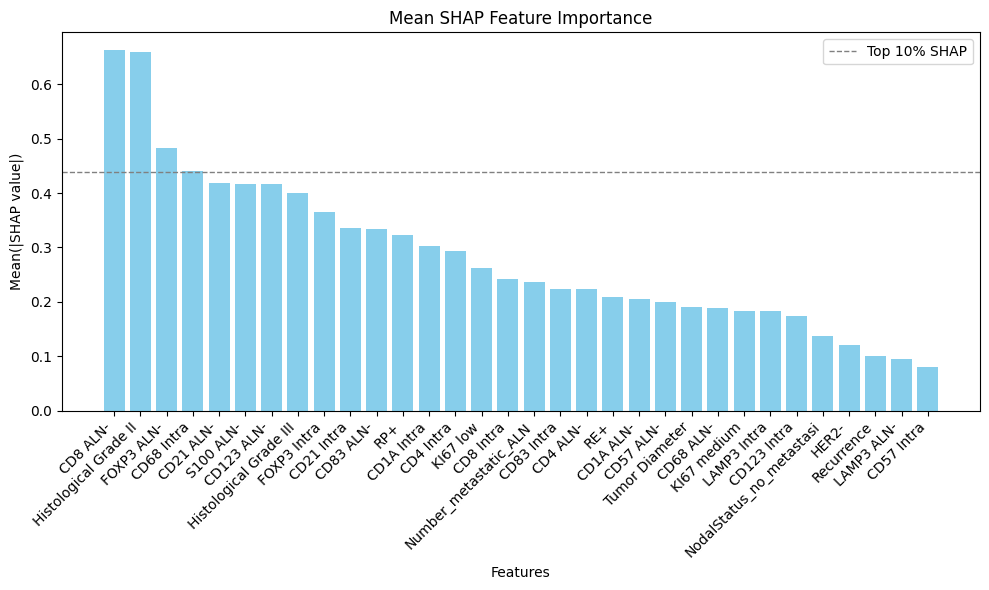

In [8]:
# ----------------------------------------------------------------------------------------------------------------------------
# INITIALIZE VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
path = "../results/AgeAtDiagnosis_Model1/RECURSIVE_METHOD"

# List all subfolders (each one corresponds to a random state)
files = os.listdir(path)

# Initialize lists to store model performance metrics
AUC = []
ACCURACY = []
RECALL = []

# Initialize structures to aggregate SHAP values per feature
shap_values_dict = {}

# Counter for number of model repetitions
repetitions = 0

# ----------------------------------------------------------------------------------------------------------------------------
# LOOP THROUGH ALL RESULT FILES TO EXTRACT METRICS + SHAP VALUES
# ----------------------------------------------------------------------------------------------------------------------------
for file in files:
    full_dir = os.path.join(path, file)
    file_path = os.path.join(full_dir, "resultats_terminal.txt")

    if not os.path.exists(file_path):
        print(f"Skipping: {file_path} not found.")
        continue

    repetitions += 1

    with open(file_path, "r", encoding="latin-1") as f:  # encoding fix
        lines = f.readlines()

    parse_shap = False

    for line in lines:
        line_stripped = line.strip()

        # ---------------- METRICS ----------------
        if line_stripped.startswith("AUC:"):
            try:
                AUC.append(float(line_stripped.split(":", 1)[1].strip()))
            except ValueError:
                continue

        elif line_stripped.startswith("Accuracy:"):
            try:
                ACCURACY.append(float(line_stripped.split(":", 1)[1].strip()))
            except ValueError:
                continue

        elif line_stripped.startswith("Recall:"):
            try:
                RECALL.append(float(line_stripped.split(":", 1)[1].strip()))
            except ValueError:
                continue

        # ---------------- SHAP SECTION ----------------
        elif line_stripped == "SHAP values feature importance:":
            parse_shap = True
            continue

        elif line_stripped.startswith("SAGE feature importance"):
            parse_shap = False
            continue

        # ---------------- PARSE SHAP VALUES ----------------
        elif parse_shap:
            if ":" not in line_stripped:
                continue

            feature, value = line_stripped.split(":", 1)
            try:
                shap_value = float(value.strip())
            except ValueError:
                continue

            shap_values_dict.setdefault(feature.strip(), []).append(shap_value)


# ----------------------------------------------------------------------------------------------------------------------------
# MEAN SHAP VALUES ACROSS REPEATED RUNS
# ----------------------------------------------------------------------------------------------------------------------------
shap_values_mean_sorted = dict(
    sorted({k: np.mean(v) for k, v in shap_values_dict.items()}.items(), key=lambda x: x[1], reverse=True)
)
 
# ----------------------------------------------------------------------------------------------------------------------------
# RENAME FEATURES FOR FIGURES
# ----------------------------------------------------------------------------------------------------------------------------
rename_map = {
    'GangMeta': 'Number_metastatic_ALN'
}
 
shap_values_mean_sorted = {
    rename_map.get(k, k): v for k, v in shap_values_mean_sorted.items()
}
 
 
# ----------------------------------------------------------------------------------------------------------------------------
# METRICS: MEAN, STD, MEDIAN, IQR
# ----------------------------------------------------------------------------------------------------------------------------
metrics = {
    'AUC': AUC,
    'Accuracy': ACCURACY,
    'Recall': RECALL
}
 
for metric_name, values in metrics.items():
    values_np = np.array(values)
    mean = np.mean(values_np)
    std = np.std(values_np)
    median = np.median(values_np)
    q1 = np.percentile(values_np, 25)
    q3 = np.percentile(values_np, 75)
    iqr = q3 - q1
 
    print(f"{metric_name}:")
    print(f"  Mean = {mean:.4f}, Std = {std:.4f}")
    print(f"  Median = {median:.4f}, IQR = {iqr:.4f}\n")
 
# ----------------------------------------------------------------------------------------------------------------------------
# PLOT MEAN SHAP FEATURE IMPORTANCE
# ----------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
 
values = list(shap_values_mean_sorted.values())
 
plt.bar(shap_values_mean_sorted.keys(), values, color='skyblue')
 
# Compute top 10% cutoff
top_10_cutoff = np.percentile(values, 90)
 
# Add horizontal dashed line
plt.axhline(y=top_10_cutoff, color='gray', linestyle='--', linewidth=1, label='Top 10% SHAP')
 
plt.xlabel('Features')
plt.ylabel('Mean(|SHAP value|)')
plt.title('Mean SHAP Feature Importance')
plt.xticks(rotation=45, ha='right')
 
# Add legend
plt.legend()
 
plt.tight_layout()
plt.show()

### Model 2: Incremental Feature Model Based on Importance Ranking

In [ ]:
# ----------------------------------------------------------------------------------------------------------------------------
# IMPORT LIBRARIES
# ----------------------------------------------------------------------------------------------------------------------------
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, recall_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from imblearn.pipeline import Pipeline
import shap

# ----------------------------------------------------------------------------------------------------------------------------
# PATH
# ----------------------------------------------------------------------------------------------------------------------------
path = "../results/AgeAtDiagnosis_Model2"

input_file = "../data/Base mama FIS 2012-2014 TOR TGN Para IA.csv"

os.makedirs(path, exist_ok=True)

feature_selection_method = 'RECURSIVE'

# ----------------------------------------------------------------------------------------------------------------------------
# LOAD AND CLEAN DATA
# ----------------------------------------------------------------------------------------------------------------------------
db = pd.read_csv(input_file,
    sep=";",
)

# Replace decimal commas with decimal points
db = db.replace(',', '.', regex=True)

# Replace empty or whitespace-only strings with NaN
db = db.replace(r'^\s*$', np.nan, regex=True)

# Convert DFS120 to numeric values
db['DFS120'] = pd.to_numeric(db['DFS120'], errors='coerce')

# Remove variables that are not used in the analysis
db = db.drop(columns=['Cas', 'Stamenopa', 'OS120', 'DFS120', 'Tracneoad',
                      'Statuspesur', 'StatusOS120', 'Nºganglis', 'Invavasc',
                      'Luminal', 'Invaperin'], errors='ignore')

# Define variables that should be treated as continuous numerical features
columns_float = ['Edat', 'GangMeta', 'CD4Intra_M', 'CD4GN_M', 'CD8Intra_M', 'CD8GN_M',
                 'CD57Intra_M', 'CD57GN_M', 'FOXP3Intra_M_bis', 'FOXP3GN_M_bis',
                 'CD21Intra_M', 'CD21GN_M', 'CD68Intra_M', 'CD68GN_M', 'CD1AIntra_M',
                 'CD1AGN_M', 'CD123Intra_M', 'CD123GN_M', 'S100Intra_M', 'S100GN_M',
                 'LAMP3Intra_M', 'LAMP3GN_M', 'CD83Intra_M', 'CD83GN_M']

# Convert numerical variables to float
for col in columns_float:
    if col in db.columns:
        db[col] = db[col].astype(float)
        
# Remove S100Intra_M from the analysis (extensive missing data)
db = db.drop(columns=['S100Intra_M'], errors='ignore')

# Remove missing values and reset index
db = db.dropna().reset_index(drop=True)

print(f"Dataset shape after cleaning: {db.shape}")

# ----------------------------------------------------------------------------------------------------------------------------
# ENCODE CATEGORICAL VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
# Convert categorical variables into binary dummy variables
db = pd.get_dummies(db, columns=['Grau', 'RE', 'RP', 'HER2', 'KI67', 'NodalStatus'], drop_first=True)
db = pd.get_dummies(db, columns=['StatusDFS120'])
db = db.drop(columns=['StatusDFS120_No'], errors='ignore')

# Rename variables for readability and consistency
variable_names = ['Age', 'Tumor Diameter', 'GangMeta', 'CD4 Intra', 'CD4 ALN-', 'CD8 Intra', 'CD8 ALN-',
                  'CD57 Intra', 'CD57 ALN-', 'FOXP3 Intra', 'FOXP3 ALN-', 'CD21 Intra', 'CD21 ALN-',
                  'CD68 Intra', 'CD68 ALN-', 'CD1A Intra', 'CD1A ALN-', 'CD123 Intra', 'CD123 ALN-',
                  'S100 ALN-', 'LAMP3 Intra', 'LAMP3 ALN-', 'CD83 Intra', 'CD83 ALN-',
                  'Histological Grade II', 'Histological Grade III',
                  'RE+', 'RP+', 'HER2-',
                  'KI67 low', 'KI67 medium',
                  'NodalStatus_amb_metàstasi', 'Recaiguda']

db.columns = variable_names

# ----------------------------------------------------------------------------------------------------------------------------
# DEFINE BINARY TARGET VARIABLE
# ----------------------------------------------------------------------------------------------------------------------------
db['Age_binary'] = db['Age'].astype(float) > 60

# ----------------------------------------------------------------------------------------------------------------------------
# DEFINE FEATURE GROUPS
# ----------------------------------------------------------------------------------------------------------------------------
immune_features = ['CD4 Intra', 'CD4 ALN-', 'CD8 Intra', 'CD8 ALN-',
                  'CD57 Intra', 'CD57 ALN-', 'FOXP3 Intra', 'FOXP3 ALN-', 'CD21 Intra', 'CD21 ALN-',
                  'CD68 Intra', 'CD68 ALN-', 'CD1A Intra', 'CD1A ALN-', 'CD123 Intra', 'CD123 ALN-',
                  'S100 ALN-', 'LAMP3 Intra', 'LAMP3 ALN-', 'CD83 Intra', 'CD83 ALN-']

clinicopathological_features = [
    'Tumor Diameter',
    'GangMeta',
    'Histological Grade II',
    'Histological Grade III',
    'RE+',
    'RP+',
    'HER2-',
    'KI67 low',
    'KI67 medium',
    'NodalStatus_amb_metàstasi',
    'Recaiguda'    
]

# Combine immune and clinicopathological features
all_features = immune_features + clinicopathological_features

# Define numerical variables
variables_numericas = immune_features + ['Tumor Diameter', 'GangMeta']

# ----------------------------------------------------------------------------------------------------------------------------
# DEFINE PREDICTORS AND TARGET
# ----------------------------------------------------------------------------------------------------------------------------
x = db[all_features]
y = db['Age_binary']

print("\nOriginal distribution:")
print(Counter(y))

# ----------------------------------------------------------------------------------------------------------------------------
# SHAP-RANKED FEATURE LIST
# ----------------------------------------------------------------------------------------------------------------------------
# Features ranked according to their mean SHAP importance from Model 1
feature_list = ['CD8 ALN-', 'Histological Grade II', 'FOXP3 ALN-', 'CD68 Intra', 'CD21 ALN-', 'S100 ALN-',
                'CD123 ALN-', 'Histological Grade III', 'FOXP3 Intra', 'CD21 Intra', 'CD83 ALN-',
                'RP+', 'CD1A Intra','CD4 Intra', 'KI67 low', 'CD8 Intra', 'GangMeta', 'CD83 Intra', 
                'CD4 ALN-', 'RE+', 'CD1A ALN-', 'CD57 ALN-', 'Tumor Diameter','CD68 ALN-', 'KI67 medium', 
                'LAMP3 Intra','CD123 Intra', 'NodalStatus_no_metàstasi', 'HER2-', 'Recurrence','LAMP3 ALN-',
                'CD57 Intra']                   
                       
# Initialize the list of features included in the model
feature_using = []

# Counter to keep track of how many features have been added
feature_number = 0

# ----------------------------------------------------------------------------------------------------------------------------
# SEQUENTIAL FEATURE INCLUSION
# ----------------------------------------------------------------------------------------------------------------------------
# Sequentially add SHAP-ranked features to the model
for feature1 in feature_list:
    
    feature_using.append(feature1)
    feature_number = feature_number +1
    
    # Print the feature name to track process
    print(feature1)
    
    # Repeat the train/test split and model evaluation for 100 random states
    for i in range(0,100):
        random_num = i
        # Create directories for the current feature set and random state
        os.makedirs(f'{path}/FEATURE_{feature_number}_{feature1}',exist_ok=True)
        os.makedirs(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}',exist_ok=True)
        print('Random State:', random_num)
        
        # Create log file to record all results for this random state
        new_file = open(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}/resultats_terminal.txt', 'w')
        new_file.write('Random State: ' + str(random_num) + '\n')
        
        # ----------------------------------------------------------------------
        # TRAIN/TEST SPLIT
        # ----------------------------------------------------------------------
        # Split the dataset into training and test sets while preserving class proportions
        x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2,random_state=random_num,shuffle = True,stratify=y)
        
        # ----------------------------------------------------------------------
        # CHECK CLASS DISTRIBUTION
        # ----------------------------------------------------------------------
        # Record the class distribution in the complete dataset, training set, and test set
        counter = Counter(y)
        counter_test = Counter(y_test)
        new_file.write('\n' + 'y: '+ str(counter) + '\n')
        new_file.write('y test: ' + str(counter_test) + '\n')
        counter = Counter(y_train)
        new_file.write('y train: ' +str(counter) + '\n')
        
        # ----------------------------------------------------------------------
        # FEATURE SCALING
        # ----------------------------------------------------------------------
        # Standardize features using parameters estimated from the training set only
        scaler = StandardScaler()
        scaler_fit = scaler.fit(x_train[feature_using]) 
        
        x_train_scaled = pd.DataFrame(
        scaler_fit.transform(x_train[feature_using]), 
        columns=feature_using, 
        index=x_train.index
        )

        # Apply the training-set scaling parameters to the test set
        x_test_scaled = pd.DataFrame(
            scaler_fit.transform(x_test[feature_using]), 
            columns=feature_using, 
            index=x_test.index
        )
        
        # ----------------------------------------------------------------------
        # LOGISTIC REGRESSION HYPERPARAMETER OPTIMIZATION
        # ----------------------------------------------------------------------        
        # 3-fold stratified cross-validation
        cv = StratifiedKFold(3)

        # Define the hyperparameter search space
        param_dist = {
            'classifier__penalty': ['l1','l2'],
            'classifier__C': np.logspace(-4,4,20),
            'classifier__solver': ['liblinear','saga'],
            'classifier__max_iter': [500,1000,2000]
        }
        
        # Use ROC AUC as the optimization metric
        scoring = 'roc_auc'
        new_file.write('\n' + 'Scoring: ' + str(scoring) + '\n')

        # ----------------------------------------------------------------------
        # INITIALIZE LOGISTIC REGRESSION
        # ----------------------------------------------------------------------  
        # Initialize logistic regression with balanced class weights      
        lr_classifier =  LogisticRegression(class_weight='balanced', random_state=random_num)
          
        #----------------------------------------------------------------------
        # HYPERPARAMETER SEARCH
        #----------------------------------------------------------------------
        # Define the pipeline
        pipeline = Pipeline([
            ('classifier', lr_classifier)
        ])
        
        # Perform randomized hyperparameter search using 3-fold stratified cross-validation
        random_search = RandomizedSearchCV(estimator = pipeline, scoring = scoring, param_distributions = param_dist, cv = cv, verbose=0, random_state=random_num, n_jobs = -1)
        random_search.fit(x_train_scaled,y_train)

        # ----------------------------------------------------------------------
        # MODEL TRAINING
        # ----------------------------------------------------------------------  
        # Keep the scaled training and test sets for consistency with the previous workflow
        x_train_rfecv = x_train_scaled
        x_test_rfecv = x_test_scaled

        # Retrieve the best hyperparameters identified during the randomized search
        best_params = random_search.best_params_

        # Remove the pipeline prefix from the parameter names
        cleaned_best_params = {param.split('__')[1]: value for param, value in best_params.items()}    

        # Initialize the final logistic regression model using the optimized hyperparameters
        best_lr =  LogisticRegression(**cleaned_best_params, class_weight='balanced', random_state=random_num)

        # Fit the final model on the training set
        best_lr.fit(x_train_rfecv, y_train)

        # Generate predictions for the test set
        result_lr = best_lr.predict(x_test_rfecv)

        # ----------------------------------------------------------------------
        # CROSS-VALIDATION PERFORMANCE
        # ----------------------------------------------------------------------
        # Evaluate ROC AUC using 3-fold cross-validation on the training set
        scores = cross_val_score(best_lr, x_train_rfecv, y_train,cv=cv, scoring=scoring)
        new_file.write('\n' + 'Metricas cross_validation: ' + str(scores) )
        new_file.write('\n' + 'Media de cross_validation: ' + str(scores.mean()) +' ' + str(np.std(scores)) + '\n')

        # ----------------------------------------------------------------------
        # TEST SET PERFORMANCE
        # ----------------------------------------------------------------------
        # Generate the classification report for the test set    
        prec_rec = classification_report(y_test,result_lr)
        new_file.write('\n' + str(prec_rec) + '\n')

        # Calculate ROC AUC on the independent test set
        auc = roc_auc_score(y_test,best_lr.predict_proba(x_test_rfecv)[:, 1])
        new_file.write('\n' + 'AUC: ' + str(auc) + '\n')

        # Calculate test-set accuracy
        accuracy = accuracy_score(y_test, result_lr)
        new_file.write('\n' + 'Accuracy: ' + str(accuracy) + '\n')
        
        # ----------------------------------------------------------------------
        # LOGISTIC REGRESSION FEATURE IMPORTANCE
        # ----------------------------------------------------------------------
        # Extract logistic regression coefficients
        coefs = best_lr.coef_[0]

        # Retrieve the names of the features used by the model
        feature_names = x_test_scaled.columns if hasattr(x_test_scaled, 'columns') else np.array(feature_using)
        
        # Save feature coefficients to the results file
        new_file.write('\nFeature importances (coefficients):\n')
        for feature, coef in zip(feature_names, coefs):
            new_file.write(f"{feature}: {coef} ")
        
        # Calculate absolute coefficient values as a measure of feature importance
        coef_abs = np.abs(coefs)
        
        # Sort features according to their absolute coefficient magnitude
        coef_sorted_idx = np.argsort(coef_abs)
        sorted_features = np.array(feature_names)[coef_sorted_idx]
        sorted_importance = coef_abs[coef_sorted_idx]
        
        new_file.write('\nFeatures sorted: ' + str(sorted_features) + '\n')
        
        # Plot feature importance
        plt.grid(False)
        indices = np.arange(0, len(coef_abs)) + 0.5
        
        plt.barh(indices, sorted_importance, height=0.7)
        plt.yticks(indices, sorted_features)
        
        plt.ylim((0, len(coef_abs)))
        plt.xlabel("|Coefficient| (absolute importance)")
        plt.title("LOGISTIC REGRESSION")
        plt.savefig(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}/LR_{random_num}.png', bbox_inches='tight')
        plt.close()

        # ----------------------------------------------------------------------
        # SHAP ANALYSIS
        # ----------------------------------------------------------------------
        # Initialize the SHAP explainer for the logistic regression model
        explainer = shap.LinearExplainer(best_lr, masker=shap.maskers.Independent(x_train_rfecv))

        # Calculate SHAP values for the test set
        shap_values = explainer.shap_values(x_test_rfecv)
        new_file.write('\n' + 'SHAP values feature importance: '+ '\n')

        # Calculate mean absolute SHAP value for each feature
        shap_values_per_feature = np.abs(shap_values).mean(axis=0) 
        
        # Save mean absolute SHAP values for each feature
        cont = 0
        for feature in x_train[feature_using].columns:
            new_file.write(f'{feature}: {shap_values_per_feature[cont]}'+ '\n')
            cont = cont + 1
        
        
        # Shap summary bar plot 
        shap.summary_plot(shap_values, x_test_rfecv, show=False)
        plt.savefig(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}/shap_summary_point_{random_num}.png', bbox_inches='tight')
        plt.close()
        
        # Shap decision plot
        idx = -1  
        shap.decision_plot(explainer.expected_value, shap_values[idx, :], x_test_rfecv.columns, show=False)
        plt.savefig(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}/shap_decision_{random_num}.png', bbox_inches='tight')
        plt.close()
        
        new_file.close()


### Model 2 Statistics

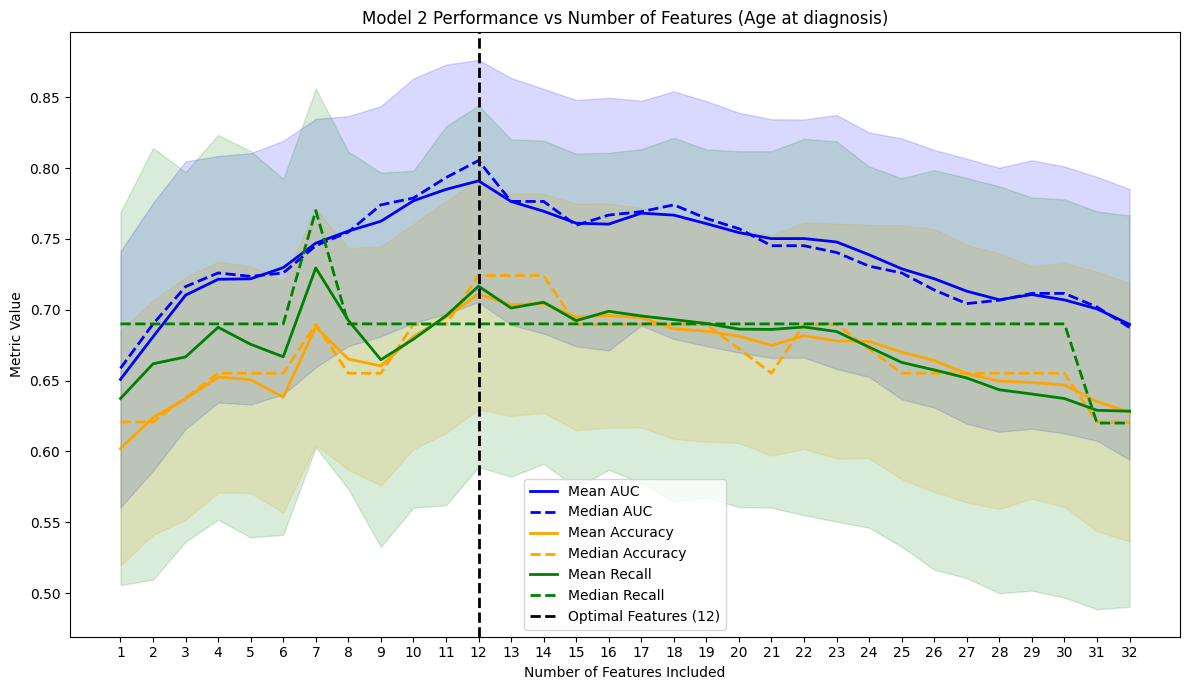


 Optimal number of features: 12

--- Final Statistics (Feature set #12) ---
AVERAGE AUC:       0.791
STD AUC:           0.085
MEDIAN AUC:        0.805
RIQ AUC:           0.141

AVERAGE ACCURACY:  0.711
STD ACCURACY:      0.081
MEDIAN ACCURACY:   0.724
RIQ ACCURACY:      0.103

AVERAGE RECALL:    0.717
STD RECALL:        0.128
MEDIAN RECALL:     0.690
RIQ RECALL:        0.098


In [7]:
# ----------------------------------------------------------------------------------------------------------------------------
# PATH
# ----------------------------------------------------------------------------------------------------------------------------
base_path = "../results/AgeAtDiagnosis_Model2"

# List all feature folders (sorted by feature number)
feature_folders = sorted(
    [f for f in os.listdir(base_path) if f.startswith("FEATURE_")],
    key=lambda x: int(x.split("_")[1])
)

# Initialize lists to store metrics for each feature count
metrics_AUC = []
metrics_Accuracy = []
metrics_Recall = []

# ----------------------------------------------------------------------------------------------------------------------------
# READ METRICS FROM ALL RESULT FILES
# ----------------------------------------------------------------------------------------------------------------------------
for folder in feature_folders:
    folder_path = os.path.join(base_path, folder)
    subfolders = [f for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]
    
    auc_list, acc_list, recall_list = [], [], []
    
    for sub in subfolders:
        result_file = os.path.join(folder_path, sub, "resultats_terminal.txt")
        if not os.path.exists(result_file):
            continue
        
        with open(result_file, "r") as f:
            lines = f.readlines()
        
        for line in lines:
            if line.startswith('AUC:'):
                auc_list.append(float(line.split(":")[1].strip()))

            elif line.startswith('Accuracy:'):
                acc_list.append(float(line.split(":")[1].strip()))

            elif line.startswith('AVERAGE RECALL:'):
                recall_list.append(float(line.split(":")[1].strip()))

            elif line.strip().startswith("True"):
                parts = line.split()
                try:
                    recall_value = float(parts[2])  # tercera columna = recall
                    recall_list.append(recall_value)
                except (ValueError, IndexError):
                    pass
    
    metrics_AUC.append(auc_list)
    metrics_Accuracy.append(acc_list)
    metrics_Recall.append(recall_list)

# ----------------------------------------------------------------------------------------------------------------------------
# COMPUTE MEAN, MEDIAN AND STD FOR EACH NUMBER OF FEATURES
# ----------------------------------------------------------------------------------------------------------------------------
mean_auc   = [np.mean(m) for m in metrics_AUC]
median_auc = [np.median(m) for m in metrics_AUC]
std_auc    = [np.std(m) for m in metrics_AUC]

mean_acc   = [np.mean(m) for m in metrics_Accuracy]
median_acc = [np.median(m) for m in metrics_Accuracy]
std_acc    = [np.std(m) for m in metrics_Accuracy]

mean_rec   = [np.mean(m) for m in metrics_Recall]
median_rec = [np.median(m) for m in metrics_Recall]
std_rec    = [np.std(m) for m in metrics_Recall]

# ----------------------------------------------------------------------------------------------------------------------------
# PLOT PERFORMANCE EVOLUTION BY NUMBER OF FEATURES
# ----------------------------------------------------------------------------------------------------------------------------
x = np.arange(1, len(mean_auc) + 1)

plt.figure(figsize=(12,7))

# AUC
plt.plot(x, mean_auc, color='blue', linewidth=2, label='Mean AUC')
plt.plot(x, median_auc, color='blue', linestyle='--', linewidth=2, label='Median AUC')

plt.fill_between(
    x,
    np.array(mean_auc) - np.array(std_auc),
    np.array(mean_auc) + np.array(std_auc),
    color='blue',
    alpha=0.15
)

# Accuracy
plt.plot(x, mean_acc, color='orange', linewidth=2, label='Mean Accuracy')
plt.plot(x, median_acc, color='orange', linestyle='--', linewidth=2, label='Median Accuracy')

plt.fill_between(
    x,
    np.array(mean_acc) - np.array(std_acc),
    np.array(mean_acc) + np.array(std_acc),
    color='orange',
    alpha=0.15
)

# Recall
plt.plot(x, mean_rec, color='green', linewidth=2, label='Mean Recall')
plt.plot(x, median_rec, color='green', linestyle='--', linewidth=2, label='Median Recall')

plt.fill_between(
    x,
    np.array(mean_rec) - np.array(std_rec),
    np.array(mean_rec) + np.array(std_rec),
    color='green',
    alpha=0.15
)

# Optimal number of features
optimal_features = np.argmax(mean_auc) + 1

plt.axvline(
    optimal_features,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Optimal Features ({optimal_features})'
)

plt.xlabel('Number of Features Included')
plt.ylabel('Metric Value')
plt.title('Model 2 Performance vs Number of Features (Age at diagnosis)')
plt.legend()
plt.xticks(x)
plt.tight_layout()
plt.show()

print(f"\n Optimal number of features: {optimal_features}")

# ----------------------------------------------------------------------------------------------------------------------------
# FINAL STATISTICS (FOR THE OPTIMAL FEATURE SET)
# ----------------------------------------------------------------------------------------------------------------------------
def metric_stats(metric_list):
    metric_list = [x for x in metric_list if not np.isnan(x)]
    if len(metric_list) == 0:
        return {"mean": np.nan, "std": np.nan, "median": np.nan, "iqr": np.nan}
    return {
        "mean": np.mean(metric_list),
        "std": np.std(metric_list),
        "median": np.median(metric_list),
        "iqr": np.percentile(metric_list, 75) - np.percentile(metric_list, 25)
    }

print(f"\n--- Final Statistics (Feature set #{optimal_features}) ---")

auc_stats = metric_stats(metrics_AUC[optimal_features - 1])
acc_stats = metric_stats(metrics_Accuracy[optimal_features - 1])
rec_stats = metric_stats(metrics_Recall[optimal_features - 1])

print(f"AVERAGE AUC:       {auc_stats['mean']:.3f}")
print(f"STD AUC:           {auc_stats['std']:.3f}")
print(f"MEDIAN AUC:        {auc_stats['median']:.3f}")
print(f"RIQ AUC:           {auc_stats['iqr']:.3f}\n")

print(f"AVERAGE ACCURACY:  {acc_stats['mean']:.3f}")
print(f"STD ACCURACY:      {acc_stats['std']:.3f}")
print(f"MEDIAN ACCURACY:   {acc_stats['median']:.3f}")
print(f"RIQ ACCURACY:      {acc_stats['iqr']:.3f}\n")

print(f"AVERAGE RECALL:    {rec_stats['mean']:.3f}")
print(f"STD RECALL:        {rec_stats['std']:.3f}")
print(f"MEDIAN RECALL:     {rec_stats['median']:.3f}")
print(f"RIQ RECALL:        {rec_stats['iqr']:.3f}")

0
1
10
11
12
13
14
15
16
17
18
19
2
20
21
22
23
24
25
26
27
28
29
3
30
31
32
33
34
35
36
37
38
39
4
40
41
42
43
44
45
46
47
48
49
5
50
51
52
53
54
55
56
57
58
59
6
60
61
62
63
64
65
66
67
68
69
7
70
71
72
73
74
75
76
77
78
79
8
80
81
82
83
84
85
86
87
88
89
9
90
91
92
93
94
95
96
97
98
99


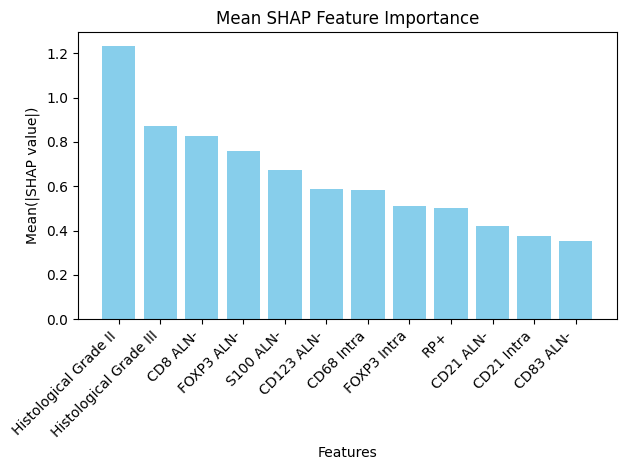

In [8]:
# ----------------------------------------------------------------------------------------------------------------------------
# INITIALIZE VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
# Define the current feature name being analyzed 
feature = "FEATURE_12_RP+"

# ----------------------------------------------------------------------------------------------------------------------------
# PATH
# ----------------------------------------------------------------------------------------------------------------------------
path1 ="../results/AgeAtDiagnosis_Model2"
path = f'{path1}/{feature}'

# List all subfolders (each one corresponds to a random state)
files = os.listdir(path)

# Initialize lists to store model performance metrics and features
AUC = []
ACCURACY = []
RECALL = []

# Initialize dictionary to aggregate SHAP values per feature
shap_values_dict = {}

# Counter for number of model repetitions
repetitions = 0

# ----------------------------------------------------------------------------------------------------------------------------
# LOOP THROUGH ALL RESULT FILES TO EXTRACT METRICS + SHAP VALUES
# ----------------------------------------------------------------------------------------------------------------------------

for file in files:
    full_dir = os.path.join(path, file)

    if not os.path.isdir(full_dir):
        continue

    file_path = os.path.join(full_dir, "resultats_terminal.txt")
    if not os.path.exists(file_path):
        print(f"Skipping: {file_path} not found.")
        continue

    repetitions += 1
    print(file)

    with open(file_path, "r", encoding="latin-1") as f:
        lines = f.readlines()

    parse_shap = False

    for line in lines:
        line_stripped = line.strip()

        # ---------------- METRICS ----------------
        if line_stripped.startswith("AUC:"):
            AUC.append(float(line_stripped.split(":", 1)[1]))

        elif line_stripped.startswith("Accuracy:"):
            ACCURACY.append(float(line_stripped.split(":", 1)[1]))

        elif line_stripped.startswith("True"):
            parts = line_stripped.split()
            if len(parts) >= 3:
                RECALL.append(float(parts[2]))

        # ---------------- SHAP SECTION ----------------
        elif line_stripped.startswith("SHAP values"):
            parse_shap = True
            continue

        # ---------------- PARSE SHAP ----------------
        elif parse_shap:
            if ":" not in line_stripped:
                continue

            feature_name, value = line_stripped.split(":", 1)

            try:
                shap_val = float(value.strip())
            except ValueError:
                continue

            shap_values_dict.setdefault(feature_name.strip(), []).append(shap_val)

# ----------------------------------------------------------------------------------------------------------------------------
# MEAN SHAP ACROSS RUNS
# ----------------------------------------------------------------------------------------------------------------------------
shap_mean = {k: np.mean(v) for k, v in shap_values_dict.items()}
shap_mean_sorted = dict(sorted(shap_mean.items(), key=lambda x: x[1], reverse=True))

# ----------------------------------------------------------------------------------------------------------------------------
# SAVE PERFORMANCE METRICS
# ----------------------------------------------------------------------------------------------------------------------------
df = pd.DataFrame({
    'AUC': AUC,
    'ACCURACY': ACCURACY,
    'RECALL': RECALL
})

df.to_excel(f'{path}/{feature}.xlsx', index=False)

with open(f'{path}/{feature}.txt', 'w') as f:
    f.write(f"Repetitions: {repetitions}\n")

# ----------------------------------------------------------------------------------------------------------------------------
# PLOT MEAN SHAP FEATURE IMPORTANCE
# ----------------------------------------------------------------------------------------------------------------------------
plt.bar(shap_mean_sorted.keys(), shap_mean_sorted.values(), color='skyblue')
plt.xlabel('Features')
plt.ylabel('Mean(|SHAP value|)')
plt.title('Mean SHAP Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Statistical Comparison: Model 1 vs. Model 2

In [ ]:
from scipy.stats import wilcoxon

# ----------------------------------------------------------------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------------------------------------------------------------

model1_path = "../results/AgeAtDiagnosis_Model1"

model2_path = "../results/AgeAtDiagnosis_Model2"

# ----------------------------------------------------------------------------------------------------------------------------
# MODEL 1 RESULTS FOLDER
# ----------------------------------------------------------------------------------------------------------------------------

model1_folder = "RECURSIVE_METHOD"

# ----------------------------------------------------------------------------------------------------------------------------
# OPTIMAL NUMBER OF FEATURES FROM MODEL 2
# ----------------------------------------------------------------------------------------------------------------------------

optimal_features = 12


# Find the corresponding FEATURE_12 folder
model2_folder = [
    f for f in os.listdir(model2_path)
    if f.startswith(f"FEATURE_{optimal_features}_")
][0]

print(f"Model 2 optimal feature set: {model2_folder}")


# ----------------------------------------------------------------------------------------------------------------------------
# FUNCTION TO EXTRACT METRICS
# ----------------------------------------------------------------------------------------------------------------------------

def extract_metrics(result_file):

    auc = np.nan
    accuracy = np.nan
    recall = np.nan

    with open(result_file, "r", encoding="latin-1") as f:
        lines = f.readlines()

    for line in lines:

        line = line.strip()

        # AUC
        if line.startswith("AUC:"):

            auc = float(
                line.split(":", 1)[1].strip()
            )

        # Accuracy
        elif line.startswith("Accuracy:"):

            accuracy = float(
                line.split(":", 1)[1].strip()
            )

        # Recall
        elif line.startswith("Recall:"):

            recall = float(
                line.split(":", 1)[1].strip()
            )

        # Recall from classification report
        elif line.startswith("True"):

            parts = line.split()

            try:

                recall_candidate = float(parts[2])

                if np.isnan(recall):

                    recall = recall_candidate

            except (ValueError, IndexError):

                pass

    return auc, accuracy, recall


# ----------------------------------------------------------------------------------------------------------------------------
# INITIALIZE VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------

model1_auc = []
model1_accuracy = []
model1_recall = []

model2_auc = []
model2_accuracy = []
model2_recall = []

paired_random_states = []


# ----------------------------------------------------------------------------------------------------------------------------
# EXTRACT PAIRED RESULTS
# ----------------------------------------------------------------------------------------------------------------------------

for random_state in range(100):

    # -------------------------------------------------------------------------
    # Model 1
    # -------------------------------------------------------------------------

    model1_file = os.path.join(
        model1_path,
        model1_folder,
        str(random_state),
        "resultats_terminal.txt"
    )

    # -------------------------------------------------------------------------
    # Model 2
    # -------------------------------------------------------------------------

    model2_file = os.path.join(
        model2_path,
        model2_folder,
        str(random_state),
        "resultats_terminal.txt"
    )

    # -------------------------------------------------------------------------
    # Check that both files exist
    # -------------------------------------------------------------------------

    if (
        not os.path.exists(model1_file)
        or not os.path.exists(model2_file)
    ):
        continue

    # -------------------------------------------------------------------------
    # Extract metrics
    # -------------------------------------------------------------------------

    auc1, acc1, rec1 = extract_metrics(model1_file)

    auc2, acc2, rec2 = extract_metrics(model2_file)

    # -------------------------------------------------------------------------
    # Keep only complete pairs
    # -------------------------------------------------------------------------

    if (
        np.isnan(auc1) or np.isnan(auc2)
        or np.isnan(acc1) or np.isnan(acc2)
        or np.isnan(rec1) or np.isnan(rec2)
    ):
        continue

    # -------------------------------------------------------------------------
    # Store paired results
    # -------------------------------------------------------------------------

    model1_auc.append(auc1)
    model2_auc.append(auc2)

    model1_accuracy.append(acc1)
    model2_accuracy.append(acc2)

    model1_recall.append(rec1)
    model2_recall.append(rec2)

    paired_random_states.append(random_state)


# ----------------------------------------------------------------------------------------------------------------------------
# NUMBER OF PAIRED REPETITIONS
# ----------------------------------------------------------------------------------------------------------------------------

print(
    f"Number of paired repetitions: "
    f"{len(paired_random_states)}"
)


# ----------------------------------------------------------------------------------------------------------------------------
# WILCOXON TEST
# ----------------------------------------------------------------------------------------------------------------------------

def run_wilcoxon(model1_values, model2_values):

    statistic, p_value = wilcoxon(
        model1_values,
        model2_values,
        alternative="two-sided"
    )

    return statistic, p_value


# ----------------------------------------------------------------------------------------------------------------------------
# AUC
# ----------------------------------------------------------------------------------------------------------------------------

auc_statistic, auc_pvalue = run_wilcoxon(
    model1_auc,
    model2_auc
)


# ----------------------------------------------------------------------------------------------------------------------------
# ACCURACY
# ----------------------------------------------------------------------------------------------------------------------------

accuracy_statistic, accuracy_pvalue = run_wilcoxon(
    model1_accuracy,
    model2_accuracy
)


# ----------------------------------------------------------------------------------------------------------------------------
# RECALL
# ----------------------------------------------------------------------------------------------------------------------------

recall_statistic, recall_pvalue = run_wilcoxon(
    model1_recall,
    model2_recall
)


# ----------------------------------------------------------------------------------------------------------------------------
# RESULTS
# ----------------------------------------------------------------------------------------------------------------------------

print("\nWILCOXON SIGNED-RANK TEST: MODEL 1 vs MODEL 2")

# AUC
print("\nAUC")
print(f"  Wilcoxon statistic: {auc_statistic:.4f}")
print(f"  p-value: {auc_pvalue:.4f}")


# Accuracy
print("\nAccuracy")
print(f"  Wilcoxon statistic: {accuracy_statistic:.4f}")
print(f"  p-value: {accuracy_pvalue:.4f}")


# Recall
print("\nRecall")
print(f"  Wilcoxon statistic: {recall_statistic:.4f}")
print(f"  p-value: {recall_pvalue:.4f}")